# Options Pricing & Risk Analysis

## Black-Scholes Options Pricing Model

This project implements the Black-Scholes model in Python to calculate theoretical prices of European Call and Put options and analyze their sensitivity to key market parameters.

### Project Objectives

- Implement the Black-Scholes pricing model
- Calculate European Call and Put option prices
- Calculate Delta, Gamma, Vega, Theta, and Rho
- Perform sensitivity analysis
- Visualize the relationship between market parameters and option values
- Validate the implementation using theoretical relationships
- Analyze the assumptions and limitations of the Black-Scholes model

**Author:** Mayank Gupta|

In [1]:
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm

# Add project root directory to Python path
sys.path.append(os.path.abspath("../"))

from src.black_scholes import (
    calculate_d1,
    calculate_d2,
    call_price,
    put_price
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Plotting configuration

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

## 1. Input Parameters

The Black-Scholes model requires five primary inputs:

| Parameter | Symbol | Description |
|---|---|---|
| Spot Price | S | Current price of the underlying asset |
| Strike Price | K | Exercise price of the option |
| Time to Maturity | T | Remaining time until expiration |
| Risk-Free Rate | r | Annual risk-free interest rate |
| Volatility | σ | Annualized volatility of the underlying asset |

For the initial analysis, we use a hypothetical underlying asset.

In [3]:
# ==========================================
# Base Option Parameters
# ==========================================

S = 2500
K = 2500
T = 1.0
r = 0.06
sigma = 0.20


print("Input Parameters")
print("=" * 40)

print(f"Spot Price       : ₹{S:.2f}")
print(f"Strike Price     : ₹{K:.2f}")
print(f"Time to Maturity : {T:.2f} years")
print(f"Risk-Free Rate   : {r * 100:.2f}%")
print(f"Volatility       : {sigma * 100:.2f}%")

Input Parameters
Spot Price       : ₹2500.00
Strike Price     : ₹2500.00
Time to Maturity : 1.00 years
Risk-Free Rate   : 6.00%
Volatility       : 20.00%


## 2. Black-Scholes Intermediate Calculations

The Black-Scholes model uses two intermediate variables, d₁ and d₂.

They are defined as:

\[
d_1 =
\frac{
\ln(S/K) + (r + \sigma^2/2)T
}{
\sigma\sqrt{T}
}
\]

\[
d_2 = d_1 - \sigma\sqrt{T}
\]

These values are used to calculate the theoretical prices of European Call and Put options.

In [4]:
# Calculate d1 and d2

d1 = calculate_d1(S, K, T, r, sigma)
d2 = calculate_d2(d1, T, sigma)

print(f"d1 = {d1:.6f}")
print(f"d2 = {d2:.6f}")

d1 = 0.400000
d2 = 0.200000


## 3. European Option Pricing

The Black-Scholes equations for European options are:

### Call Option

\[
C = SN(d_1) - Ke^{-rT}N(d_2)
\]

### Put Option

\[
P = Ke^{-rT}N(-d_2) - SN(-d_1)
\]

where \(N(\cdot)\) represents the cumulative distribution function of the standard normal distribution.

In [5]:
# Calculate European Call and Put prices

call = call_price(S, K, T, r, sigma)
put = put_price(S, K, T, r, sigma)

print(f"European Call Price : ₹{call:.2f}")
print(f"European Put Price  : ₹{put:.2f}")

European Call Price : ₹274.74
European Put Price  : ₹129.15


## 4. Initial Model Results

The following table summarizes the model inputs and calculated theoretical option prices.

In [6]:
results = pd.DataFrame({
    "Parameter": [
        "Spot Price",
        "Strike Price",
        "Volatility",
        "Risk-Free Rate",
        "Maturity",
        "Call Price",
        "Put Price"
    ],
    "Value": [
        f"₹{S:.2f}",
        f"₹{K:.2f}",
        f"{sigma * 100:.2f}%",
        f"{r * 100:.2f}%",
        f"{T:.2f} years",
        f"₹{call:.2f}",
        f"₹{put:.2f}"
    ]
})

results

,Parameter,Value
0,Spot Price,₹2500.00
1,Strike Price,₹2500.00
2,Volatility,20.00%
3,Risk-Free Rate,6.00%
4,Maturity,1.00 years
5,Call Price,₹274.74
6,Put Price,₹129.15


## 5. Model Validation — Put-Call Parity

Put-Call Parity provides a theoretical relationship between European Call and Put options having the same strike price and expiration date.

\[
C - P = S - Ke^{-rT}
\]

This relationship provides a useful validation check for our implementation.

In [7]:
# ==========================================
# Put-Call Parity Validation
# ==========================================

left_side = call - put
right_side = S - K * np.exp(-r * T)

difference = abs(left_side - right_side)

print("Put-Call Parity Validation")
print("=" * 40)

print(f"C - P         : ₹{left_side:.6f}")
print(f"S - Ke^(-rT)  : ₹{right_side:.6f}")

print("-" * 40)

print(f"Absolute Difference : ₹{difference:.10f}")

if difference < 1e-10:
    print("\n✓ Put-Call Parity Validation PASSED")
else:
    print("\n✗ Put-Call Parity Validation FAILED")

Put-Call Parity Validation
C - P         : ₹145.588666
S - Ke^(-rT)  : ₹145.588666
----------------------------------------
Absolute Difference : ₹0.0000000000

✓ Put-Call Parity Validation PASSED


## 6. Option Greeks

Option Greeks measure the sensitivity of an option's theoretical value to changes in different model parameters.

| Greek | Measures Sensitivity To |
|---|---|
| Delta | Underlying asset price |
| Gamma | Change in Delta |
| Vega | Volatility |
| Theta | Time to maturity |
| Rho | Risk-free interest rate |

These measures are useful for understanding the risk characteristics of an option position.

In [8]:
import sys
import os

project_root = os.path.abspath("../")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Project root:", project_root)

Project root: c:\Users\ASUS\OneDrive\Desktop\Black scholes option analysis


In [9]:
from src.black_scholes import (
    delta,
    gamma,
    vega,
    theta,
    rho,
    option_analysis
)

print("Greeks imported successfully!")

Greeks imported successfully!


In [10]:
# ==========================================
# Calculate Option Greeks
# ==========================================

call_delta = delta(S, K, T, r, sigma, "call")
put_delta = delta(S, K, T, r, sigma, "put")

gamma_value = gamma(S, K, T, r, sigma)

vega_value = vega(S, K, T, r, sigma)

call_theta = theta(
    S, K, T, r, sigma, "call"
)

put_theta = theta(
    S, K, T, r, sigma, "put"
)

call_rho = rho(
    S, K, T, r, sigma, "call"
)

put_rho = rho(
    S, K, T, r, sigma, "put"
)

print("Option Greeks")
print("=" * 45)

print(f"Call Delta : {call_delta:.6f}")
print(f"Put Delta  : {put_delta:.6f}")
print(f"Gamma      : {gamma_value:.6f}")
print(f"Vega       : {vega_value:.6f}")
print(f"Call Theta : {call_theta:.6f}")
print(f"Put Theta  : {put_theta:.6f}")
print(f"Call Rho   : {call_rho:.6f}")
print(f"Put Rho    : {put_rho:.6f}")

Option Greeks
Call Delta : 0.655422
Put Delta  : -0.344578
Gamma      : 0.000737
Vega       : 920.675351
Call Theta : -0.476429
Put Theta  : -0.089402
Call Rho   : 1363.815625
Put Rho    : -990.595709


## 8. Greek Validation Checks

Before performing sensitivity analysis, the calculated Greeks are validated using theoretical relationships of the Black-Scholes model.

The checks include:

1. Call-Put Delta relationship
2. Call-Put Rho relationship
3. Gamma consistency between Call and Put options

In [11]:
# ==========================================
# Delta Validation
# ==========================================

delta_difference = call_delta - put_delta

print("Delta Validation")
print("=" * 45)

print(f"Call Delta       : {call_delta:.6f}")
print(f"Put Delta        : {put_delta:.6f}")
print(f"Call - Put Delta : {delta_difference:.6f}")

print("-" * 45)

if abs(delta_difference - 1) < 1e-10:
    print("✓ Delta relationship PASSED")
else:
    print("✗ Delta relationship FAILED")

Delta Validation
Call Delta       : 0.655422
Put Delta        : -0.344578
Call - Put Delta : 1.000000
---------------------------------------------
✓ Delta relationship PASSED


In [12]:
# ==========================================
# Gamma Validation
# ==========================================

call_gamma = gamma(S, K, T, r, sigma)
put_gamma = gamma(S, K, T, r, sigma)

gamma_difference = abs(call_gamma - put_gamma)

print("Gamma Validation")
print("=" * 45)

print(f"Call Gamma : {call_gamma:.8f}")
print(f"Put Gamma  : {put_gamma:.8f}")
print(f"Difference : {gamma_difference:.10f}")

print("-" * 45)

if gamma_difference < 1e-10:
    print("✓ Gamma consistency PASSED")
else:
    print("✗ Gamma consistency FAILED")

Gamma Validation
Call Gamma : 0.00073654
Put Gamma  : 0.00073654
Difference : 0.0000000000
---------------------------------------------
✓ Gamma consistency PASSED


## 9. Complete Black-Scholes Results

In [13]:
# ==========================================
# Complete Results Table
# ==========================================

complete_results = pd.DataFrame({
    "Parameter": [
        "Spot Price",
        "Strike Price",
        "Time to Maturity",
        "Risk-Free Rate",
        "Volatility",
        "Call Price",
        "Put Price",
        "Call Delta",
        "Put Delta",
        "Gamma",
        "Vega",
        "Call Theta",
        "Put Theta",
        "Call Rho",
        "Put Rho"
    ],

    "Value": [
        f"₹{S:.2f}",
        f"₹{K:.2f}",
        f"{T:.2f} years",
        f"{r * 100:.2f}%",
        f"{sigma * 100:.2f}%",
        f"₹{call:.2f}",
        f"₹{put:.2f}",
        f"{call_delta:.6f}",
        f"{put_delta:.6f}",
        f"{gamma_value:.8f}",
        f"{vega_value:.2f}",
        f"{call_theta:.6f}",
        f"{put_theta:.6f}",
        f"{call_rho:.2f}",
        f"{put_rho:.2f}"
    ]
})

complete_results

,Parameter,Value
0,Spot Price,₹2500.00
1,Strike Price,₹2500.00
2,Time to Maturity,1.00 years
3,Risk-Free Rate,6.00%
4,Volatility,20.00%
5,Call Price,₹274.74
6,Put Price,₹129.15
7,Call Delta,0.655422
8,Put Delta,-0.344578
9,Gamma,0.00073654


In [14]:
# ==========================================
# Reusable Option Analysis Engine
# ==========================================

analysis = option_analysis(
    S, K, T, r, sigma
)

analysis

{'call_price': np.float64(274.73872881564967),
 'put_price': np.float64(129.15006277627162),
 'call_delta': np.float64(0.6554217416103242),
 'put_delta': np.float64(-0.3445782583896758),
 'gamma': np.float64(0.0007365402806066467),
 'vega': np.float64(920.6753507583084),
 'call_theta': np.float64(-0.4764286920231246),
 'put_theta': np.float64(-0.0894021713720635),
 'call_rho': np.float64(1363.8156252101608),
 'put_rho': np.float64(-990.5957087504612)}

In [15]:
# ==========================================
# Engine Test with Different Parameters
# ==========================================

test_S = 2800
test_K = 2700
test_T = 0.5
test_r = 0.065
test_sigma = 0.25

test_analysis = option_analysis(
    test_S,
    test_K,
    test_T,
    test_r,
    test_sigma
)

print("Test Option")
print("=" * 45)

for metric, value in test_analysis.items():
    print(f"{metric:15s}: {value:.6f}")

Test Option
call_price     : 298.059777
put_price      : 111.720392
call_delta     : 0.683662
put_delta      : -0.316338
gamma          : 0.000719
vega           : 704.605775
call_theta     : -0.770422
put_theta      : -0.304975
call_rho       : 808.096321
put_rho        : -498.733986


# 10. Sensitivity Analysis

Sensitivity analysis evaluates how the theoretical value and risk characteristics of European options change when one Black-Scholes input is varied while the remaining parameters are held constant.

The four key parameters analyzed are:

1. Underlying Spot Price
2. Volatility
3. Strike Price
4. Time to Maturity

The base-case parameters are used as the reference point for each analysis.

## 10.1 Sensitivity to Underlying Asset Price

The spot price of the underlying asset is varied while keeping strike price, volatility, interest rate, and maturity constant.

This analysis helps examine how option prices and Delta/Gamma respond to movements in the underlying asset.

In [16]:
# ==========================================
# Spot Price Sensitivity Analysis
# ==========================================

spot_prices = np.linspace(1800, 3200, 100)

spot_sensitivity = []

for spot in spot_prices:

    call = call_price(
        spot, K, T, r, sigma
    )

    put = put_price(
        spot, K, T, r, sigma
    )

    call_delta = delta(
        spot, K, T, r, sigma, "call"
    )

    gamma_value = gamma(
        spot, K, T, r, sigma
    )

    spot_sensitivity.append({
        "Spot Price": spot,
        "Call Price": call,
        "Put Price": put,
        "Call Delta": call_delta,
        "Gamma": gamma_value
    })

spot_df = pd.DataFrame(spot_sensitivity)

spot_df.head()

,Spot Price,Call Price,Put Price,Call Delta,Gamma
0,1800.000000,17.053315,571.464648,0.107022,0.000512
1,1814.141414,18.618665,558.888585,0.114412,0.000533
2,1828.282828,20.290607,546.419113,0.122097,0.000554
3,1842.424242,22.073291,534.060382,0.130074,0.000574
4,1856.565657,23.970822,521.816499,0.138339,0.000595


### Call and Put Prices vs Spot Price

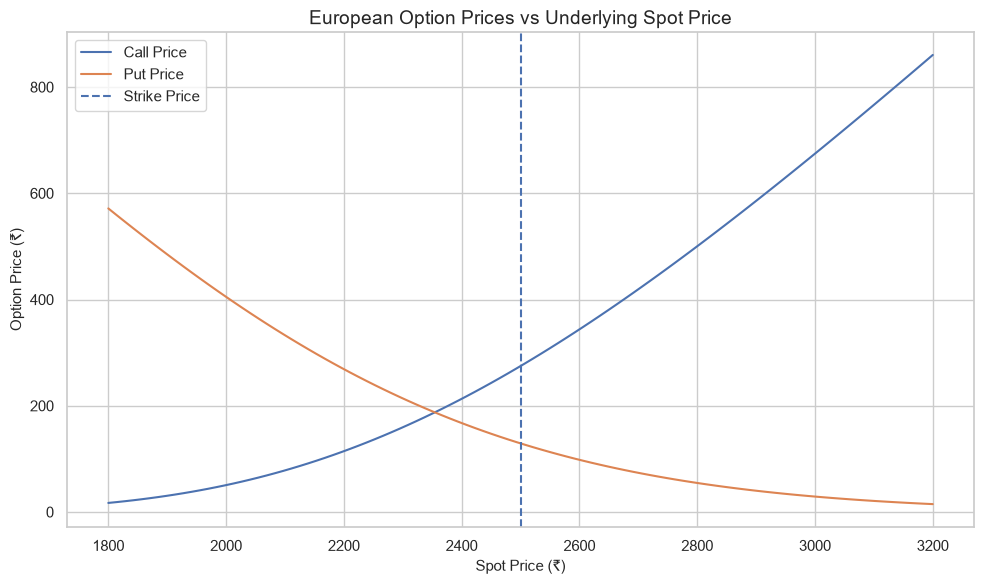

In [32]:
plt.figure(figsize=(10, 6))

plt.plot(
    spot_df["Spot Price"],
    spot_df["Call Price"],
    label="Call Price"
)

plt.plot(
    spot_df["Spot Price"],
    spot_df["Put Price"],
    label="Put Price"
)

plt.axvline(
    K,
    linestyle="--",
    label="Strike Price"
)

plt.title("European Option Prices vs Underlying Spot Price")
plt.xlabel("Spot Price (₹)")
plt.ylabel("Option Price (₹)")

plt.legend()
plt.tight_layout()

plt.savefig(
    "../visualization/charts/01_option_prices_vs_spot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Call Delta vs Spot Price

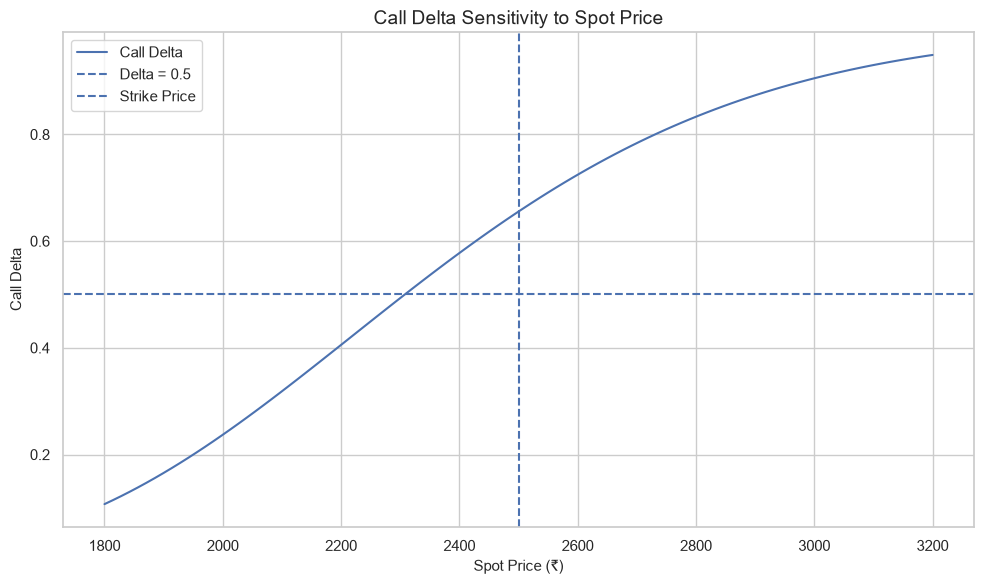

In [33]:
plt.figure(figsize=(10, 6))

plt.plot(
    spot_df["Spot Price"],
    spot_df["Call Delta"],
    label="Call Delta"
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Delta = 0.5"
)

plt.axvline(
    K,
    linestyle="--",
    label="Strike Price"
)

plt.title("Call Delta Sensitivity to Spot Price")
plt.xlabel("Spot Price (₹)")
plt.ylabel("Call Delta")

plt.legend()
plt.tight_layout()

plt.savefig(
    "../visualization/charts/02_call_delta_vs_spot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Gamma vs Spot Price

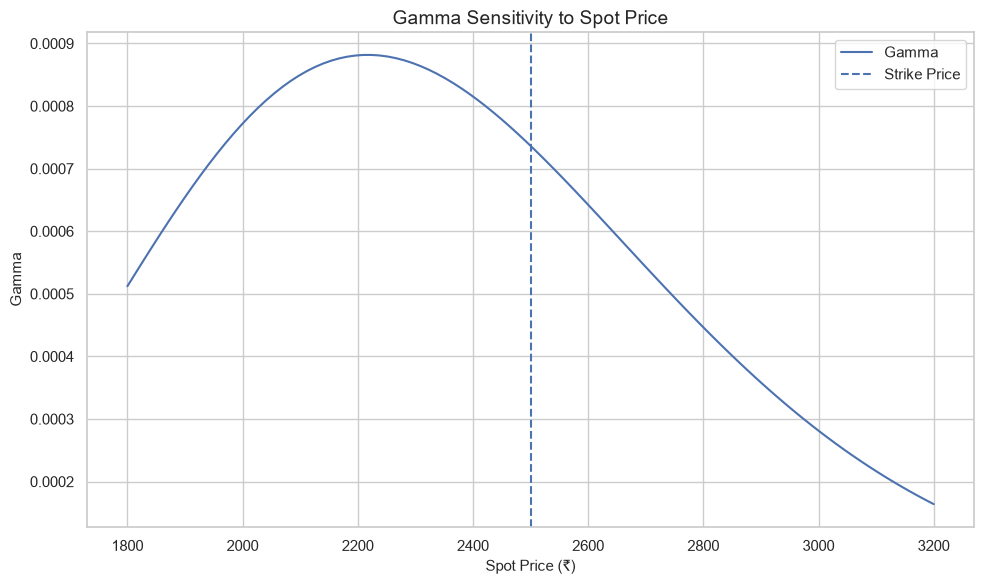

In [34]:
plt.figure(figsize=(10, 6))

plt.plot(
    spot_df["Spot Price"],
    spot_df["Gamma"],
    label="Gamma"
)

plt.axvline(
    K,
    linestyle="--",
    label="Strike Price"
)

plt.title("Gamma Sensitivity to Spot Price")
plt.xlabel("Spot Price (₹)")
plt.ylabel("Gamma")

plt.legend()
plt.tight_layout()

plt.savefig(
    "../visualization/charts/03_gamma_vs_spot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10.2 Sensitivity to Volatility

Volatility represents the expected variability of the underlying asset's returns.

The analysis evaluates how changes in volatility affect theoretical Call and Put prices and Vega.

In [20]:
# ==========================================
# Volatility Sensitivity Analysis
# ==========================================

volatilities = np.linspace(0.10, 0.50, 100)

volatility_sensitivity = []

for vol in volatilities:

    call = call_price(
        S, K, T, r, vol
    )

    put = put_price(
        S, K, T, r, vol
    )

    vega_value = vega(
        S, K, T, r, vol
    )

    volatility_sensitivity.append({
        "Volatility": vol,
        "Call Price": call,
        "Put Price": put,
        "Vega": vega_value
    })

volatility_df = pd.DataFrame(
    volatility_sensitivity
)

volatility_df.head()

,Volatility,Call Price,Put Price,Vega
0,0.100000,186.483056,40.894390,807.430899
1,0.104040,189.768144,44.179478,818.491934
2,0.108081,193.095648,47.506982,828.450411
3,0.112121,196.461391,50.872725,837.441387
4,0.116162,199.861705,54.273039,845.580551


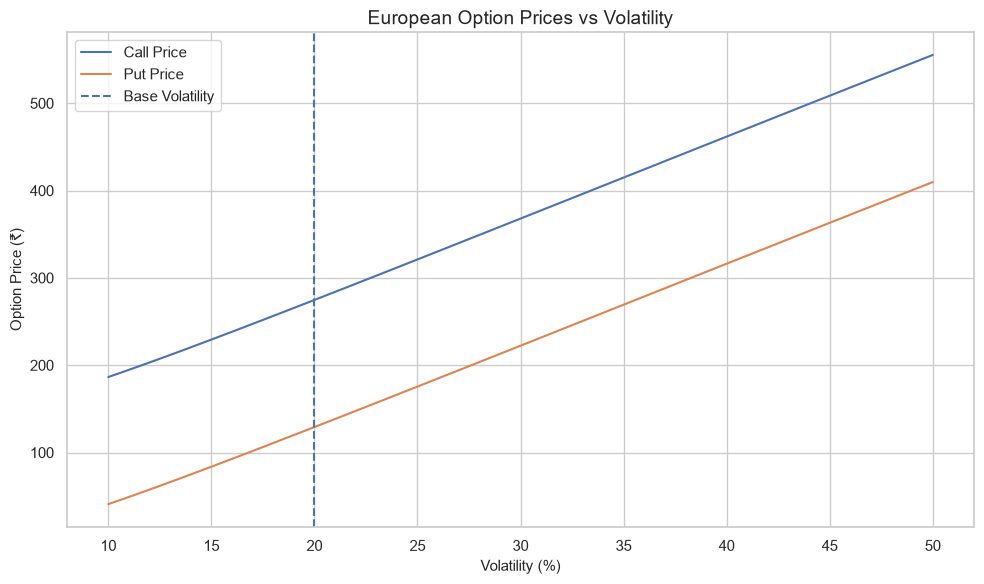

In [35]:
plt.figure(figsize=(10, 6))

plt.plot(
    volatility_df["Volatility"] * 100,
    volatility_df["Call Price"],
    label="Call Price"
)

plt.plot(
    volatility_df["Volatility"] * 100,
    volatility_df["Put Price"],
    label="Put Price"
)

plt.axvline(
    sigma * 100,
    linestyle="--",
    label="Base Volatility"
)

plt.title("European Option Prices vs Volatility")
plt.xlabel("Volatility (%)")
plt.ylabel("Option Price (₹)")

plt.legend()
plt.tight_layout()

plt.savefig(
    "../visualization/charts/04_option_prices_vs_volatility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Vega vs Volatility

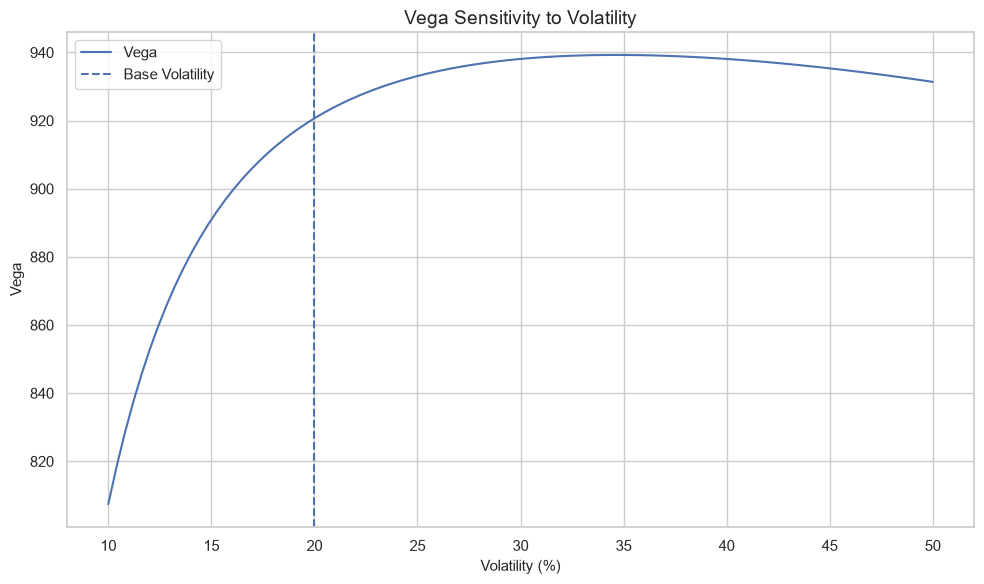

In [40]:
plt.figure(figsize=(10, 6))

plt.plot(
    volatility_df["Volatility"] * 100,
    volatility_df["Vega"],
    label="Vega"
)

plt.axvline(
    sigma * 100,
    linestyle="--",
    label="Base Volatility"
)

plt.title("Vega Sensitivity to Volatility")
plt.xlabel("Volatility (%)")
plt.ylabel("Vega")

plt.legend()
plt.tight_layout()

plt.savefig(
    "../visualization/charts/05_vega_vs_volatility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10.3 Sensitivity to Strike Price

The strike price is varied while all other Black-Scholes parameters remain constant.

This analysis demonstrates how the moneyness of an option affects its theoretical value.

In [23]:
# ==========================================
# Strike Price Sensitivity Analysis
# ==========================================

strike_prices = np.linspace(2000, 3000, 100)

strike_sensitivity = []

for strike in strike_prices:

    call = call_price(
        S, strike, T, r, sigma
    )

    put = put_price(
        S, strike, T, r, sigma
    )

    strike_sensitivity.append({
        "Strike Price": strike,
        "Call Price": call,
        "Put Price": put
    })

strike_df = pd.DataFrame(
    strike_sensitivity
)

strike_df.head()

,Strike Price,Call Price,Put Price
0,2000.00000,631.787384,15.316452
1,2010.10101,623.190444,16.232284
2,2020.20202,614.634969,17.189583
3,2030.30303,606.122095,18.189481
4,2040.40404,597.652954,19.233113


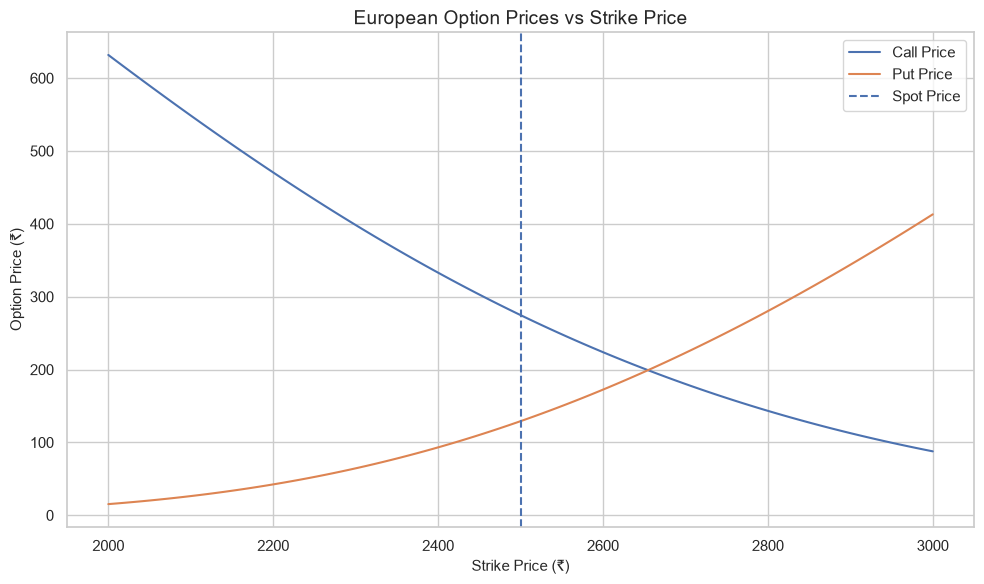

In [41]:
plt.figure(figsize=(10, 6))

plt.plot(
    strike_df["Strike Price"],
    strike_df["Call Price"],
    label="Call Price"
)

plt.plot(
    strike_df["Strike Price"],
    strike_df["Put Price"],
    label="Put Price"
)

plt.axvline(
    S,
    linestyle="--",
    label="Spot Price"
)

plt.title("European Option Prices vs Strike Price")
plt.xlabel("Strike Price (₹)")
plt.ylabel("Option Price (₹)")

plt.legend()
plt.tight_layout()

plt.savefig(
    "../visualization/charts/06_option_prices_vs_strike.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10.4 Sensitivity to Time to Maturity

Time to maturity represents the remaining life of the option.

This analysis examines how increasing the time available for the underlying asset to move affects theoretical option values and Theta.

In [25]:
# ==========================================
# Time to Maturity Sensitivity Analysis
# ==========================================

maturities = np.linspace(0.1, 2.0, 100)

maturity_sensitivity = []

for maturity in maturities:

    call = call_price(
        S, K, maturity, r, sigma
    )

    put = put_price(
        S, K, maturity, r, sigma
    )

    call_theta = theta(
        S, K, maturity, r, sigma, "call"
    )

    maturity_sensitivity.append({
        "Time to Maturity": maturity,
        "Call Price": call,
        "Put Price": put,
        "Call Theta": call_theta
    })

maturity_df = pd.DataFrame(
    maturity_sensitivity
)

maturity_df.head()

,Time to Maturity,Call Price,Put Price,Call Theta
0,0.100000,70.639358,55.684269,-1.071752
1,0.119192,77.881793,60.066783,-0.999204
2,0.138384,84.674595,64.002956,-0.942318
3,0.157576,91.108663,67.583683,-0.896158
4,0.176768,97.247821,70.872784,-0.857724


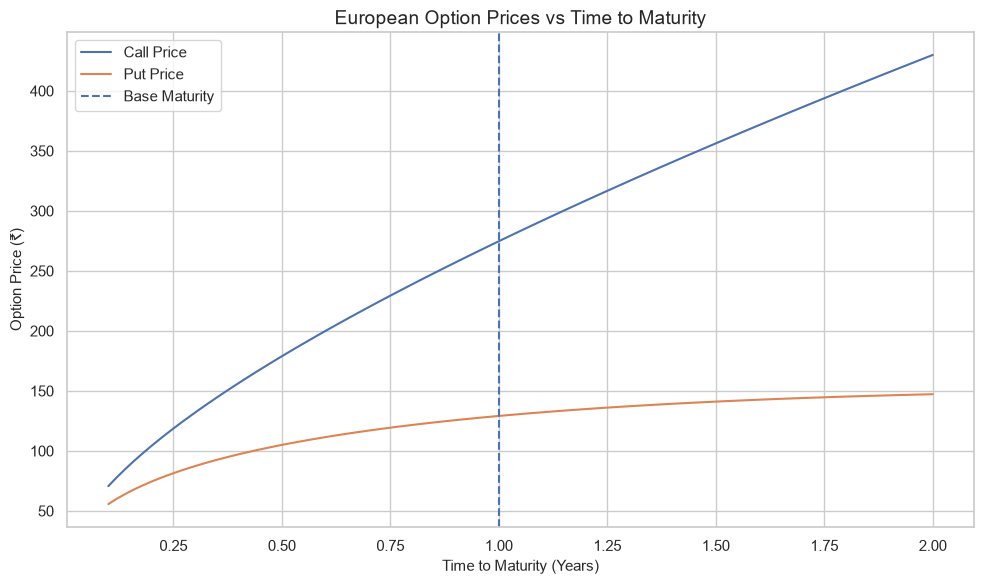

In [38]:
plt.figure(figsize=(10, 6))

plt.plot(
    maturity_df["Time to Maturity"],
    maturity_df["Call Price"],
    label="Call Price"
)

plt.plot(
    maturity_df["Time to Maturity"],
    maturity_df["Put Price"],
    label="Put Price"
)

plt.axvline(
    T,
    linestyle="--",
    label="Base Maturity"
)

plt.title("European Option Prices vs Time to Maturity")
plt.xlabel("Time to Maturity (Years)")
plt.ylabel("Option Price (₹)")

plt.legend()
plt.tight_layout()

plt.savefig(
    "../visualization/charts/07_option_prices_vs_maturity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 11. Sensitivity Analysis Results

The sensitivity analysis demonstrates how the Black-Scholes theoretical option value and Greeks respond to changes in the underlying model parameters.

For each analysis, one parameter is varied while the remaining parameters are held constant at their base-case values.

In [27]:
# ==========================================
# Sensitivity Analysis Summary
# ==========================================

sensitivity_summary = pd.DataFrame({
    "Parameter": [
        "Spot Price",
        "Volatility",
        "Strike Price",
        "Time to Maturity"
    ],

    "Base Value": [
        f"₹{S:.0f}",
        f"{sigma * 100:.0f}%",
        f"₹{K:.0f}",
        f"{T:.1f} year"
    ],

    "Analysis Range": [
        "₹1,800 - ₹3,200",
        "10% - 50%",
        "₹2,000 - ₹3,000",
        "0.1 - 2.0 years"
    ],

    "Primary Impact": [
        "Call/Put Price, Delta, Gamma",
        "Call/Put Price, Vega",
        "Call/Put Price",
        "Call/Put Price, Theta"
    ]
})

sensitivity_summary

,Parameter,Base Value,Analysis Range,Primary Impact
0,Spot Price,₹2500,"₹1,800 - ₹3,200","Call/Put Price, Delta, Gamma"
1,Volatility,20%,10% - 50%,"Call/Put Price, Vega"
2,Strike Price,₹2500,"₹2,000 - ₹3,000",Call/Put Price
3,Time to Maturity,1.0 year,0.1 - 2.0 years,"Call/Put Price, Theta"


## 11.1 Impact of Spot Price

In [28]:
# ==========================================
# Spot Price Impact
# ==========================================

spot_low = spot_df.iloc[0]
spot_high = spot_df.iloc[-1]

call_change_spot = (
    (spot_high["Call Price"] - spot_low["Call Price"])
    / spot_low["Call Price"]
) * 100

put_change_spot = (
    (spot_high["Put Price"] - spot_low["Put Price"])
    / spot_low["Put Price"]
) * 100

print("Spot Price Sensitivity")
print("=" * 50)

print(
    f"Spot Price: ₹{spot_low['Spot Price']:.0f}"
    f" → ₹{spot_high['Spot Price']:.0f}"
)

print(
    f"Call Price: ₹{spot_low['Call Price']:.2f}"
    f" → ₹{spot_high['Call Price']:.2f}"
)

print(
    f"Call Price Change: {call_change_spot:.2f}%"
)

print(
    f"Put Price: ₹{spot_low['Put Price']:.2f}"
    f" → ₹{spot_high['Put Price']:.2f}"
)

print(
    f"Put Price Change: {put_change_spot:.2f}%"
)

Spot Price Sensitivity
Spot Price: ₹1800 → ₹3200
Call Price: ₹17.05 → ₹860.41
Call Price Change: 4945.39%
Put Price: ₹571.46 → ₹14.82
Put Price Change: -97.41%


## 11.2 Impact of Volatility

In [29]:
# ==========================================
# Volatility Impact
# ==========================================

vol_low = volatility_df.iloc[0]
vol_high = volatility_df.iloc[-1]

call_change_vol = (
    (vol_high["Call Price"] - vol_low["Call Price"])
    / vol_low["Call Price"]
) * 100

put_change_vol = (
    (vol_high["Put Price"] - vol_low["Put Price"])
    / vol_low["Put Price"]
) * 100

print("Volatility Sensitivity")
print("=" * 50)

print(
    f"Volatility: "
    f"{vol_low['Volatility'] * 100:.0f}%"
    f" → "
    f"{vol_high['Volatility'] * 100:.0f}%"
)

print(
    f"Call Price: ₹{vol_low['Call Price']:.2f}"
    f" → ₹{vol_high['Call Price']:.2f}"
)

print(
    f"Call Price Change: {call_change_vol:.2f}%"
)

print(
    f"Put Price: ₹{vol_low['Put Price']:.2f}"
    f" → ₹{vol_high['Put Price']:.2f}"
)

print(
    f"Put Price Change: {put_change_vol:.2f}%"
)   

Volatility Sensitivity
Volatility: 10% → 50%
Call Price: ₹186.48 → ₹555.33
Call Price Change: 197.79%
Put Price: ₹40.89 → ₹409.74
Put Price Change: 901.95%


## 11.3 Impact of Strike Price

In [30]:
# ==========================================
# Strike Price Impact
# ==========================================

strike_low = strike_df.iloc[0]
strike_high = strike_df.iloc[-1]

call_change_strike = (
    (strike_high["Call Price"] - strike_low["Call Price"])
    / strike_low["Call Price"]
) * 100

put_change_strike = (
    (strike_high["Put Price"] - strike_low["Put Price"])
    / strike_low["Put Price"]
) * 100

print("Strike Price Sensitivity")
print("=" * 50)

print(
    f"Strike Price: ₹{strike_low['Strike Price']:.0f}"
    f" → ₹{strike_high['Strike Price']:.0f}"
)

print(
    f"Call Price: ₹{strike_low['Call Price']:.2f}"
    f" → ₹{strike_high['Call Price']:.2f}"
)

print(
    f"Call Price Change: {call_change_strike:.2f}%"
)

print(
    f"Put Price: ₹{strike_low['Put Price']:.2f}"
    f" → ₹{strike_high['Put Price']:.2f}"
)

print(
    f"Put Price Change: {put_change_strike:.2f}%"
)

Strike Price Sensitivity
Strike Price: ₹2000 → ₹3000
Call Price: ₹631.79 → ₹87.74
Call Price Change: -86.11%
Put Price: ₹15.32 → ₹413.03
Put Price Change: 2596.65%


## 11.4 Impact of Time to Maturity

In [31]:
# ==========================================
# Time to Maturity Impact
# ==========================================

maturity_low = maturity_df.iloc[0]
maturity_high = maturity_df.iloc[-1]

call_change_maturity = (
    (maturity_high["Call Price"] - maturity_low["Call Price"])
    / maturity_low["Call Price"]
) * 100

put_change_maturity = (
    (maturity_high["Put Price"] - maturity_low["Put Price"])
    / maturity_low["Put Price"]
) * 100

print("Time to Maturity Sensitivity")
print("=" * 50)

print(
    f"Maturity: "
    f"{maturity_low['Time to Maturity']:.1f}"
    f" → "
    f"{maturity_high['Time to Maturity']:.1f} years"
)

print(
    f"Call Price: ₹{maturity_low['Call Price']:.2f}"
    f" → ₹{maturity_high['Call Price']:.2f}"
)

print(
    f"Call Price Change: {call_change_maturity:.2f}%"
)

print(
    f"Put Price: ₹{maturity_low['Put Price']:.2f}"
    f" → ₹{maturity_high['Put Price']:.2f}"
)

print(
    f"Put Price Change: {put_change_maturity:.2f}%"
)

Time to Maturity Sensitivity
Maturity: 0.1 → 2.0 years
Call Price: ₹70.64 → ₹429.94
Call Price Change: 508.64%
Put Price: ₹55.68 → ₹147.24
Put Price Change: 164.42%


## 12. Key Findings

The sensitivity analysis produced the following observations:

### 1. Spot Price

- European Call option value increases as the underlying asset price increases.
- European Put option value generally decreases as the underlying asset price increases.
- Call Delta increases with the underlying asset price.
- Gamma is concentrated around the at-the-money region, indicating greater sensitivity of Delta near the strike price.

### 2. Volatility

- Both Call and Put option values generally increase as volatility increases.
- Vega measures the sensitivity of option value to changes in volatility.
- Higher volatility increases the range of possible future underlying prices, increasing the value of optionality.

### 3. Strike Price

- Call option value generally decreases as the strike price increases.
- Put option value generally increases as the strike price increases.
- Strike price therefore has an important influence on the moneyness and theoretical value of an option.

### 4. Time to Maturity

- Increasing time to maturity generally increases the theoretical value of both European Call and Put options.
- Longer maturity provides more time for favorable movements in the underlying asset.
- Theta captures the effect of the passage of time on option value and is particularly important as expiration approaches.

In [42]:
# ==========================================
# Export Sensitivity Analysis Data
# ==========================================

spot_df.to_csv(
    "../data/spot_price_sensitivity.csv",
    index=False
)

volatility_df.to_csv(
    "../data/volatility_sensitivity.csv",
    index=False
)

strike_df.to_csv(
    "../data/strike_price_sensitivity.csv",
    index=False
)

maturity_df.to_csv(
    "../data/maturity_sensitivity.csv",
    index=False
)

print("Sensitivity datasets exported successfully!")

Sensitivity datasets exported successfully!


# 13. Market Data Analysis

## 13.1 Historical Market Data

To connect the theoretical Black-Scholes model with real-world market data, historical prices of Reliance Industries Limited are retrieved using Yahoo Finance through the `yfinance` Python library.

The historical data is used to calculate daily returns and estimate annualized historical volatility.

In [43]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Market data libraries imported successfully!")

Market data libraries imported successfully!


In [44]:
# ==========================================
# Download Historical Market Data
# ==========================================

ticker_symbol = "RELIANCE.NS"

reliance = yf.Ticker(ticker_symbol)

market_data = reliance.history(
    period="2y",
    interval="1d",
    auto_adjust=True
)

print("Historical data downloaded successfully!")
print(f"Number of observations: {len(market_data)}")

market_data.head()

Historical data downloaded successfully!
Number of observations: 501


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2024-09-25 00:00:00+05:30,1471.194813,1483.686907,1467.526419,1481.158691,7069002,0.0,0.0
2024-09-26 00:00:00+05:30,1477.887087,1491.122760,1475.309372,1485.124512,18818998,0.0,0.0
2024-09-27 00:00:00+05:30,1486.165535,1520.345335,1479.225469,1513.107910,20597478,0.0,0.0
2024-09-30 00:00:00+05:30,1506.390899,1511.918118,1461.776190,1463.932495,27008814,0.0,0.0
2024-10-01 00:00:00+05:30,1467.972660,1475.210084,1450.300205,1452.283081,16431642,0.0,0.0


In [45]:
# ==========================================
# Clean Market Data
# ==========================================

market_data = market_data[["Open", "High", "Low", "Close", "Volume"]].copy()

market_data.dropna(inplace=True)

print("Data cleaning completed.")
print(f"Remaining observations: {len(market_data)}")

market_data.tail()

Data cleaning completed.
Remaining observations: 501


,Open,High,Low,Close,Volume
Date,,,,,
2026-09-21 00:00:00+05:30,1234.099976,1249.099976,1232.500000,1247.400024,10007218
2026-09-22 00:00:00+05:30,1247.599976,1251.900024,1237.400024,1240.400024,10684376
2026-09-23 00:00:00+05:30,1242.000000,1252.800049,1238.900024,1248.000000,8352048
2026-09-24 00:00:00+05:30,1236.599976,1241.599976,1219.199951,1219.199951,13923795
2026-09-25 00:00:00+05:30,1210.500000,1227.400024,1210.500000,1226.000000,13108409


In [46]:
# ==========================================
# Calculate Daily Returns
# ==========================================

market_data["Daily Return"] = market_data["Close"].pct_change()

market_data.dropna(inplace=True)

print("Daily returns calculated successfully!")

market_data[["Close", "Daily Return"]].head()

Daily returns calculated successfully!


,Close,Daily Return
Date,,
2024-09-26 00:00:00+05:30,1485.124512,0.002678
2024-09-27 00:00:00+05:30,1513.107910,0.018842
2024-09-30 00:00:00+05:30,1463.932495,-0.032500
2024-10-01 00:00:00+05:30,1452.283081,-0.007958
2024-10-03 00:00:00+05:30,1394.928467,-0.039493


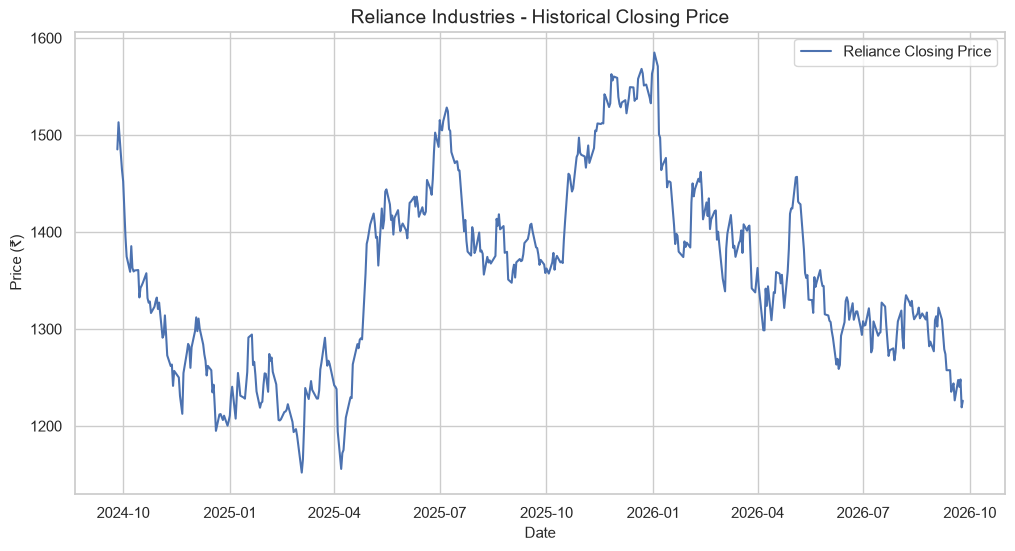

In [47]:
# ==========================================
# Historical Closing Price
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(
    market_data.index,
    market_data["Close"],
    label="Reliance Closing Price"
)

plt.title("Reliance Industries - Historical Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True)

plt.savefig(
    "../visualization/charts/08_reliance_historical_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [48]:
# ==========================================
# Daily Return Analysis
# ==========================================

print("Daily Return Statistics")
print("=" * 50)

print(
    f"Mean Daily Return : "
    f"{market_data['Daily Return'].mean():.6f}"
)

print(
    f"Daily Volatility  : "
    f"{market_data['Daily Return'].std():.6f}"
)

print(
    f"Minimum Return    : "
    f"{market_data['Daily Return'].min():.6f}"
)

print(
    f"Maximum Return    : "
    f"{market_data['Daily Return'].max():.6f}"
)

Daily Return Statistics
Mean Daily Return : -0.000292
Daily Volatility  : 0.013133
Minimum Return    : -0.045998
Maximum Return    : 0.052599


In [49]:
# ==========================================
# Annualized Historical Volatility
# ==========================================

daily_volatility = market_data["Daily Return"].std()

annualized_volatility = daily_volatility * np.sqrt(252)

print("Historical Volatility")
print("=" * 50)

print(f"Daily Volatility      : {daily_volatility:.4%}")
print(f"Annualized Volatility : {annualized_volatility:.4%}")

Historical Volatility
Daily Volatility      : 1.3133%
Annualized Volatility : 20.8484%


In [50]:
sigma = 0.20

In [51]:
# ==========================================
# Latest Market Price
# ==========================================

market_spot_price = market_data["Close"].iloc[-1]

print("Latest Market Information")
print("=" * 50)

print(f"Underlying Asset : Reliance Industries")
print(f"Ticker           : {ticker_symbol}")
print(f"Latest Price     : ₹{market_spot_price:.2f}")
print(f"Historical Vol.  : {annualized_volatility:.2%}")

Latest Market Information
Underlying Asset : Reliance Industries
Ticker           : RELIANCE.NS
Latest Price     : ₹1226.00
Historical Vol.  : 20.85%


In [52]:
# ==========================================
# Compare Assumed vs Historical Volatility
# ==========================================

assumed_volatility = sigma

print("Volatility Comparison")
print("=" * 50)

print(
    f"Assumed Volatility     : "
    f"{assumed_volatility:.2%}"
)

print(
    f"Historical Volatility  : "
    f"{annualized_volatility:.2%}"
)

print(
    f"Difference             : "
    f"{annualized_volatility - assumed_volatility:.2%}"
)

Volatility Comparison
Assumed Volatility     : 20.00%
Historical Volatility  : 20.85%
Difference             : 0.85%


## 13.2 Black-Scholes Pricing Using Historical Market Data

The latest observed underlying price and annualized historical volatility are used as inputs to the Black-Scholes pricing engine.

The strike price is set equal to the observed underlying price to represent an approximately at-the-money option, while the risk-free rate and maturity remain fixed for demonstration purposes.

In [53]:
# ==========================================
# Black-Scholes Using Real Market Data
# ==========================================

market_S = market_spot_price
market_K = market_spot_price
market_T = 1.0
market_r = 0.06
market_sigma = annualized_volatility

market_option_result = option_analysis(
    S=market_S,
    K=market_K,
    T=market_T,
    r=market_r,
    sigma=market_sigma
)

market_option_result

{'call_price': np.float64(138.5685584170824),
 'put_price': np.float64(67.1718765913713),
 'call_delta': np.float64(0.6524834274180751),
 'put_delta': np.float64(-0.3475165725819249),
 'gamma': np.float64(0.001445351625334574),
 'vega': np.float64(452.92578536591765),
 'call_theta': np.float64(-0.2380724434967743),
 'put_theta': np.float64(-0.048274637769493936),
 'call_rho': np.float64(661.3761235974777),
 'put_rho': np.float64(-493.22719457681126)}

In [54]:
# ==========================================
# Market-Based Black-Scholes Results
# ==========================================

market_results = pd.DataFrame({
    "Parameter": [
        "Underlying",
        "Spot Price",
        "Strike Price",
        "Time to Maturity",
        "Risk-Free Rate",
        "Historical Volatility",
        "Call Price",
        "Put Price",
        "Call Delta",
        "Put Delta",
        "Gamma",
        "Vega",
        "Call Theta",
        "Put Theta",
        "Call Rho",
        "Put Rho"
    ],

    "Value": [
        "Reliance Industries",
        f"₹{market_S:.2f}",
        f"₹{market_K:.2f}",
        f"{market_T:.2f} years",
        f"{market_r:.2%}",
        f"{market_sigma:.2%}",
        f"₹{market_option_result['call_price']:.2f}",
        f"₹{market_option_result['put_price']:.2f}",
        f"{market_option_result['call_delta']:.6f}",
        f"{market_option_result['put_delta']:.6f}",
        f"{market_option_result['gamma']:.6f}",
        f"{market_option_result['vega']:.6f}",
        f"{market_option_result['call_theta']:.6f}",
        f"{market_option_result['put_theta']:.6f}",
        f"{market_option_result['call_rho']:.6f}",
        f"{market_option_result['put_rho']:.6f}"
    ]
})

market_results

,Parameter,Value
0,Underlying,Reliance Industries
1,Spot Price,₹1226.00
2,Strike Price,₹1226.00
3,Time to Maturity,1.00 years
4,Risk-Free Rate,6.00%
5,Historical Volatility,20.85%
6,Call Price,₹138.57
7,Put Price,₹67.17
8,Call Delta,0.652483
9,Put Delta,-0.347517


In [55]:
# ==========================================
# Save Market Data
# ==========================================

market_data.to_csv(
    "../data/reliance_historical_data.csv"
)

print("Market data saved successfully!")

Market data saved successfully!


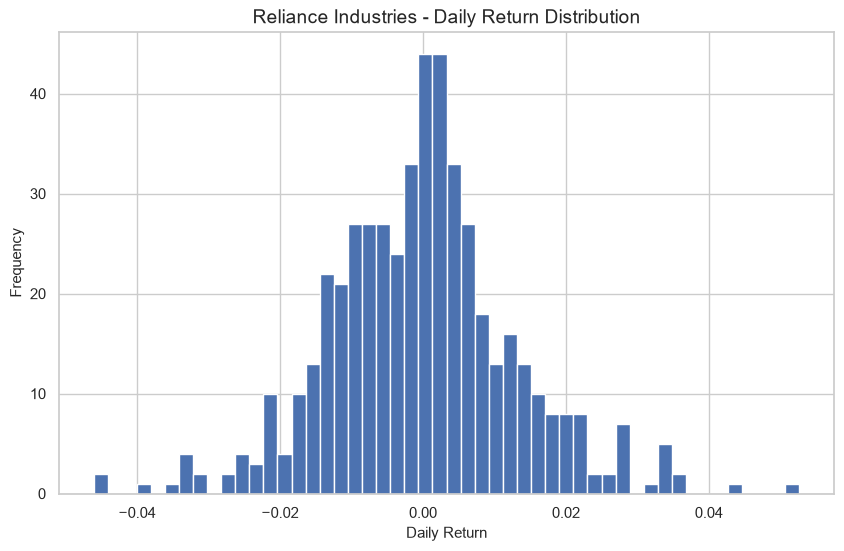

In [56]:
# ==========================================
# Daily Return Distribution
# ==========================================

plt.figure(figsize=(10, 6))

plt.hist(
    market_data["Daily Return"],
    bins=50
)

plt.title("Reliance Industries - Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True)

plt.savefig(
    "../visualization/charts/09_reliance_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 13.3 Market Data Findings

The historical market-data analysis provides a data-driven estimate of the underlying asset's volatility.

Key observations:

- Historical daily returns were calculated from the adjusted closing prices.
- Daily volatility was annualized using the square-root-of-time approach with 252 trading days.
- The resulting historical volatility was used as the volatility input for the Black-Scholes model.
- The latest observed underlying price was used as the spot price.
- Using market-derived inputs produces a theoretical option valuation that reflects the historical behavior of the underlying asset.
- The result remains a theoretical Black-Scholes valuation and should not be interpreted as an observed market option price.

### Important Limitation

Historical volatility is backward-looking, whereas option prices in financial markets generally reflect forward-looking expectations of volatility. Therefore, historical volatility and implied volatility can differ significantly.

Other assumptions of the basic Black-Scholes model, including constant volatility, constant risk-free rate, frictionless markets, and continuous trading assumptions, also limit the model's ability to perfectly represent real-world option prices.

# 14. Final Results & Consolidated Analysis

This section summarizes the key outputs generated by the Black-Scholes pricing model and the market-data analysis.

The project combines theoretical option pricing, option Greeks, sensitivity analysis, and historical market data to study how changes in market parameters affect European option valuation.

In [57]:
# Final consolidated results

final_results = pd.DataFrame({
    "Metric": [
        "Underlying Asset",
        "Spot Price",
        "Strike Price",
        "Time to Maturity",
        "Risk-Free Rate",
        "Volatility Used",
        "European Call Price",
        "European Put Price",
        "Call Delta",
        "Put Delta",
        "Gamma",
        "Vega",
        "Call Theta",
        "Put Theta",
        "Call Rho",
        "Put Rho"
    ],
    "Value": [
        "Reliance Industries",
        f"₹{market_S:.2f}",
        f"₹{market_K:.2f}",
        f"{market_T:.2f} years",
        f"{market_r:.2%}",
        f"{market_sigma:.2%}",
        f"₹{market_option_result['call_price']:.2f}",
        f"₹{market_option_result['put_price']:.2f}",
        f"{market_option_result['call_delta']:.6f}",
        f"{market_option_result['put_delta']:.6f}",
        f"{market_option_result['gamma']:.6f}",
        f"{market_option_result['vega']:.6f}",
        f"{market_option_result['call_theta']:.6f}",
        f"{market_option_result['put_theta']:.6f}",
        f"{market_option_result['call_rho']:.6f}",
        f"{market_option_result['put_rho']:.6f}"
    ]
})

final_results

,Metric,Value
0,Underlying Asset,Reliance Industries
1,Spot Price,₹1226.00
2,Strike Price,₹1226.00
3,Time to Maturity,1.00 years
4,Risk-Free Rate,6.00%
5,Volatility Used,20.85%
6,European Call Price,₹138.57
7,European Put Price,₹67.17
8,Call Delta,0.652483
9,Put Delta,-0.347517


# 15. Model Assumptions & Limitations

The Black-Scholes model is based on several assumptions that simplify real-world financial markets.

## 15.1 Key Assumptions

- The option is a European option and can only be exercised at expiration.
- The underlying asset price follows a continuous stochastic process.
- Volatility remains constant throughout the option's lifetime.
- The risk-free interest rate remains constant.
- Markets are frictionless, with no transaction costs or taxes.
- The underlying asset does not pay dividends in the basic model.
- Trading is assumed to be continuous.
- The underlying asset is sufficiently liquid to allow the theoretical assumptions of the model.

## 15.2 Practical Limitations

- Historical volatility is backward-looking and may differ from future or implied volatility.
- Real market volatility changes over time rather than remaining constant.
- Actual option prices are affected by supply and demand, liquidity, transaction costs, and market expectations.
- The basic model does not account for dividends.
- The model is designed for European-style options and does not directly represent early-exercise features of American options.
- Interest rates and other market parameters can change over time.
- Therefore, Black-Scholes should be interpreted as a theoretical pricing framework rather than an exact prediction of observed market prices.

## 15.3 Interpretation

The purpose of this project is to demonstrate how option prices and Greeks respond to changes in important financial variables.

The sensitivity analysis and historical market-data analysis help illustrate the relationship between market parameters and theoretical option valuation.